# Notebook for Support Vector Regression and SHAPLY calculation

#### Imports

In [2]:
import pandas as pd
import importlib
from SVR import svr_machine_learning

importlib.reload(svr_machine_learning)

<module 'SVR.svr_machine_learning' from 'C:\\Users\\Minh\\Desktop\\Psycho Arbeit\\Psycho_DataspellProjekt\\SVR\\svr_machine_learning.py'>

#### Machine Learning Variables

In [3]:
# ===========================
# SVR Notebook Settings
# ===========================

my_target_column = "How happy are you?"
my_test_size = 0.2
my_random_state = 42

# SVR baseline parameters
my_svr_kernel = "rbf"
my_svr_C = 1.0
my_svr_epsilon = 0.1

# SHAP settings
my_number_of_shaply_rows = 5000
my_number_header_rows = 150

##### Model 1A Optimized

In [5]:
# Load data
data = pd.read_csv('../data/data_eqls_LOOSE_filtered.csv')

model_1A_optimized, shap_results_1A_optimized = svr_machine_learning.run_svr_gridsearch_and_shap(
    df=data,
    target_column=my_target_column,
    test_size=my_test_size,
    random_state=my_random_state,
    shap_rows=my_number_of_shaply_rows,
    number_header_rows=my_number_header_rows
)


Fitting 3 folds for each of 9 candidates, totalling 27 fits
✅ RMSE: 1.2884
✅ R²: 0.4191
🔍 Starting SHAP for 5000 rows...


 11%|█         | 134/1225 [04:27<36:12,  1.99s/it] C:\Users\Minh\anaconda3\envs\Psycho_DataspellProjekt\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 8 iterations, i.e. alpha=1.017e-02, with an active set of 8 regressors, and the smallest cholesky pivot element being 8.429e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
 44%|████▍     | 545/1225 [18:34<24:04,  2.12s/it]  C:\Users\Minh\anaconda3\envs\Psycho_DataspellProjekt\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 4 iterations, i.e. alpha=7.206e-03, with an active set of 4 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
 56%|█████▋    | 691/1225 [23:34<34:56,  3.93s/it]C:\Users\Minh\anaconda3\envs\Psycho_DataspellProjekt\Lib\site-packages\


Top SHAP features:
                                          Questions     Value  Direction
121                 How satisfied with family life?  0.140466  -0.045360
119  How satisfied with present standard of living?  0.122727  -0.004196
123                 How satisfied with social life?  0.106334  -0.014836
30                                 Health condition  0.056902  -0.007381
122                      How satisfied with health?  0.038508  -0.007922
..                                              ...       ...        ...
51       Difficult to see a doctor because of cost?  0.002346   0.000663
134                                 Country_Belgium  0.002336   0.000689
16                                    Country group  0.002286   0.000242
34              Problems with accommodation - space  0.002157  -0.000139
21             Phone/internet contact with children  0.002040   0.000673

[150 rows x 3 columns]

✅ Best Parameters: {'C': 1, 'epsilon': 0.2, 'kernel': 'rbf'}


In [6]:
# Save results
shap_results_1A_optimized.to_csv("Results/shap_results_1A_opzimized.csv", index=False)

##### Model 1B - No 'How satisfied with...' questions - Hyperparameter optimized

In [4]:
# Load data
data = pd.read_csv('../data/data_eqls_LOOSE_filtered.csv')
my_target_column = 'How happy are you?'
print("Shape before: ", data.shape)

# Drop 'How satisfied with...' columns
# They have too much predictive value and there are similar questions
# e.g. "Health condition", "Quality of education system?", "Feel left out of sociey?"
columns_to_remove = [
    'How satisfied with present standard of living?',
    'How satisfied with family life?',
    'How satisfied with social life?',
    'How satisfied with health?',
    'How satisfied with economic situation in the country?',
    'How satisfied with accommodation?',
    'How satisfied with education?'
]
data.drop(columns=columns_to_remove, inplace=True, errors='ignore')
print("Shape after: ", data.shape)

model_1B_optimized, shap_results_1B_optimized = svr_machine_learning.run_svr_gridsearch_and_shap(
    df=data,
    target_column=my_target_column,
    test_size=my_test_size,
    random_state=my_random_state,
    cv_folds=3,
    shap_rows=my_number_of_shaply_rows,
    number_header_rows=my_number_header_rows
)

Shape before:  (6122, 168)
Shape after:  (6122, 161)
Fitting 3 folds for each of 9 candidates, totalling 27 fits
✅ RMSE: 1.4133
✅ R²: 0.3011
🔍 Starting SHAP for 5000 rows...


  0%|          | 0/1225 [00:00<?, ?it/s]

C:\Users\Minh\anaconda3\envs\happiness_project\Lib\site-packages\sklearn\linear_model\_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 8 iterations, i.e. alpha=2.178e-02, with an active set of 8 regressors, and the smallest cholesky pivot element being 8.429e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
C:\Users\Minh\anaconda3\envs\happiness_project\Lib\site-packages\shap\explainers\_kernel.py:708: UserWarning: Linear regression equation is singular, a least squares solutions is used instead.
To avoid this situation and get a regular matrix do one of the following:
1) turn up the number of samples,
2) turn up the L1 regularization with num_features(N) where N is less than the number of samples,
3) group features together to reduce the number of inputs that need to be explained.
  warnings.warn(
C:\Users\Minh\anaconda3\envs\happiness_project\Lib\site-packages\shap\explainers\_kernel.py:708: UserWarning: Linear 


Top SHAP features:
                                             Questions     Value  Direction
30                                    Health condition  0.132676  -0.006833
115  I generally feel that what I do in life is wor...  0.069171   0.004669
116     I feel I am free to decide how to live my life  0.047586  -0.014440
114                   I am optimistic about the future  0.038753  -0.003475
94   Can't find the way because life has become so ...  0.027528  -0.002051
..                                                 ...       ...        ...
104  Can afford a meal with meat/chicken/fish every...  0.002067   0.000281
147                                      Country_Malta  0.001952  -0.001952
151                                   Country_Portugal  0.001593  -0.001593
128                                   Country_Bulgaria  0.001506  -0.001245
149                                Country_Netherlands  0.001105  -0.000867

[150 rows x 3 columns]

✅ Best Parameters: {'C': 1, 'epsilon': 0.2,

In [5]:
# Save results
shap_results_1B_optimized.to_csv("Results/shap_results_1B_opzimized.csv", index=False)

# Plots

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import textwrap

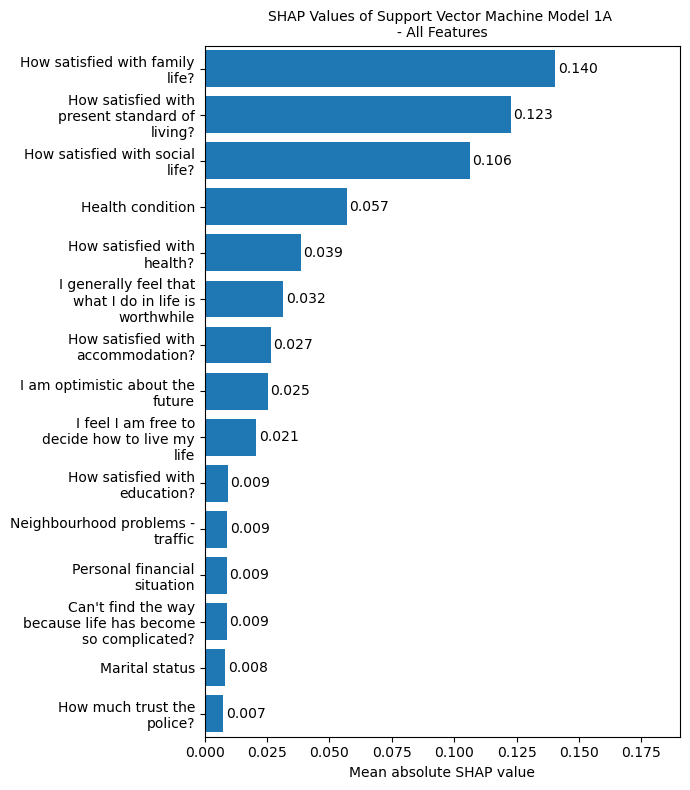

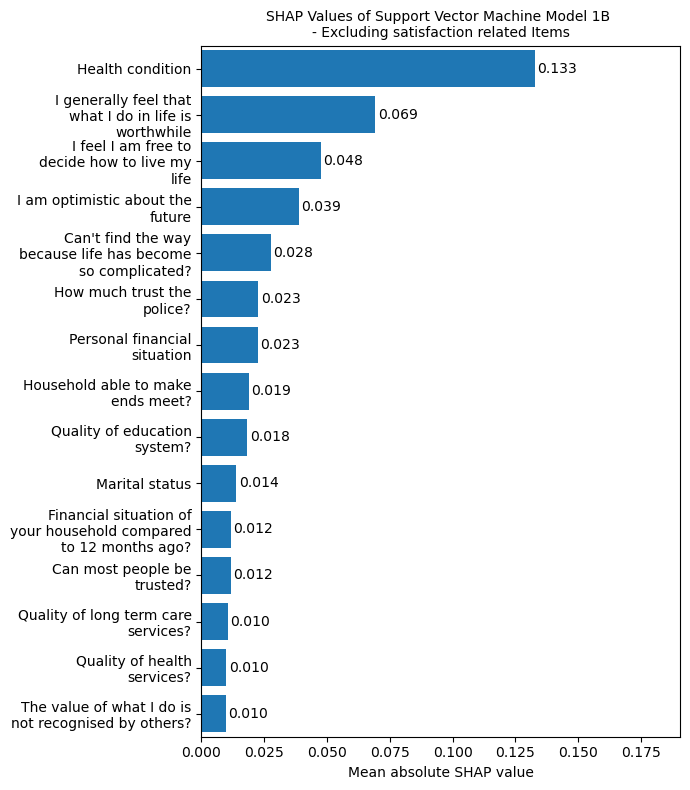

In [3]:
# Load Data
df_1A = pd.read_csv("Results/shap_results_1A_opzimized.csv")
df_1B = pd.read_csv("Results/shap_results_1B_opzimized.csv")

def plot_shap_large(df, title, max_questions=None):


    df_sorted = df.sort_values(by="Value", ascending=True).reset_index(drop=True)
    if max_questions:
        df_sorted = df_sorted.tail(max_questions).reset_index(drop=True)

    df_sorted["Questions"] = df_sorted["Questions"].apply(lambda x: "\n".join(textwrap.wrap(x, width=25)))

    n = len(df_sorted)
    #plt.figure(figsize=(5.5, n * 0.6))
    plt.figure(figsize=(7, 8))
    bars = plt.barh(df_sorted["Questions"], df_sorted["Value"])

    # title
    plt.xlabel("Mean absolute SHAP value", color='black', fontsize=10)
    plt.title(title, color='black', fontsize=10)

    xlim_max = max(
        df_1A["Value"].max(),
        df_1B["Value"].max()
    )
    plt.xlim(0, xlim_max+0.05)

    # Display values in the bars
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.001,
                 bar.get_y() + bar.get_height() / 2,
                 f"{width:.3f}",
                 va='center', fontsize=10)

    plt.ylim(-0.5, n - 0.5)
    plt.tight_layout()
    plt.show()

# Show plots
plot_shap_large(df_1A, "SHAP Values of Support Vector Machine Model 1A \n- All Features", max_questions=15)
plot_shap_large(df_1B, "SHAP Values of Support Vector Machine Model 1B \n- Excluding satisfaction related Items", max_questions=15)
plt.show()